<a href="https://colab.research.google.com/github/RabinPhuyal/Customer-Churn-Prediction-Neural-Network/blob/main/Customer_Churn_Prediction_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction Using PyTorch

A neural network binary classification project that predicts whether a customer is likely to churn.

## Objectives
- Explore customer churn data
- Clean and preprocess the dataset
- Perform exploratory data analysis
- Build a neural network using PyTorch
- Train and validate the model
- Evaluate classification performance
- Analyze overfitting and improve the model

In [2]:
#Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

print("PyTorch Version: ",torch.__version__)

PyTorch Version:  2.11.0+cpu


In [3]:
import os

os.listdir()

['.config', 'WA_Fn-UseC_-Telco-Customer-Churn.csv', 'sample_data']

In [4]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [10]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [11]:
df["Churn"].value_counts(normalize=True)*100

,proportion
Churn,
No,73.463013
Yes,26.536987


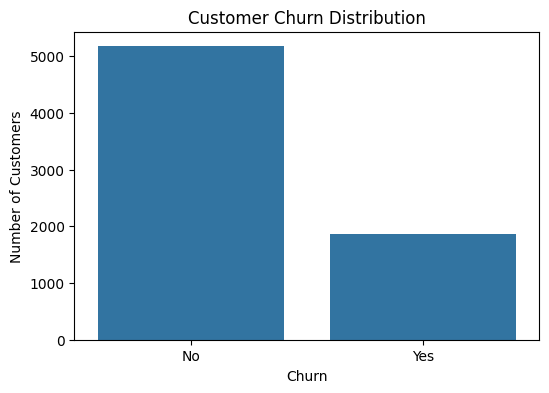

In [12]:
#Visualize Churn Distribution
plt.figure(figsize = (6,4))
sns.countplot(data=df, x= "Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

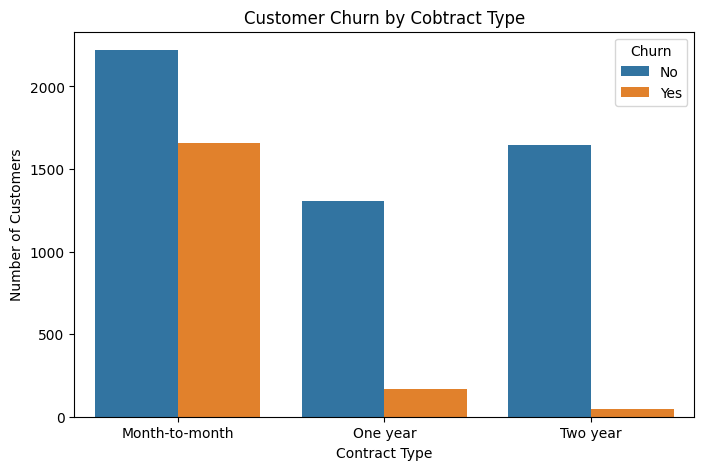

In [13]:
#Does Contract Type Affect Churn?
plt.figure(figsize=(8,5))
sns.countplot(data=df, x= "Contract", hue="Churn")

plt.title("Customer Churn by Cobtract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

In [14]:
#Calculat the churn rate
contract_churn = pd.crosstab(df["Contract"],df["Churn"], normalize="index") *100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


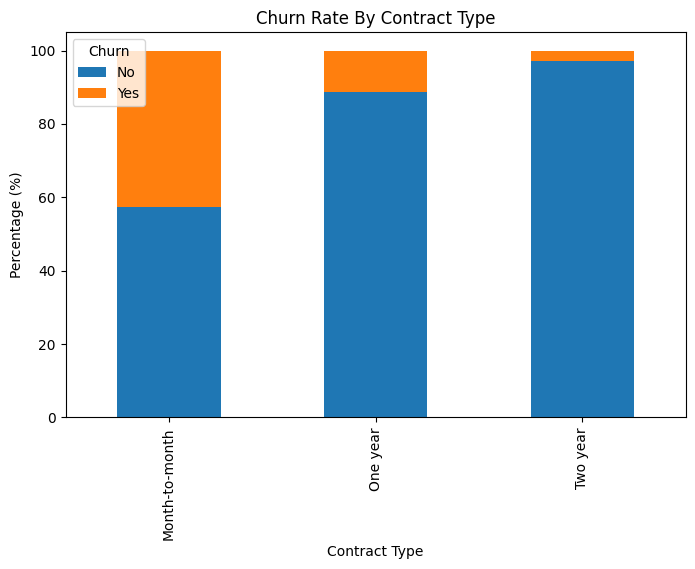

In [15]:
#Visualize the percentages
contract_churn.plot(
    kind="bar",
    stacked= True,
    figsize= (8,5)
)
plt.title("Churn Rate By Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.legend(title="Churn")

plt.show()

The analysis indicates that month-to-month customers have a substantially higher churn rate than customers on longer-term contracts. This suggests that contract duration may be an important predictor of customer retention.

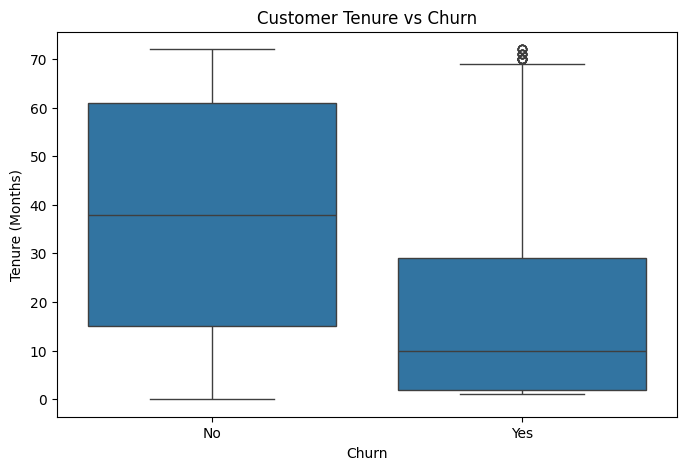

In [16]:
#Do Customers With Shorter Tenure Churn More?

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)
plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

Customers who churn tend to have shorter tenure than customers who remain with the company, indicating that early-stage customers may represent a higher-risk segment.

In [17]:
#Calculate average tenure
df.groupby("Churn")["tenure"].mean()

,tenure
Churn,
No,37.569965
Yes,17.979133


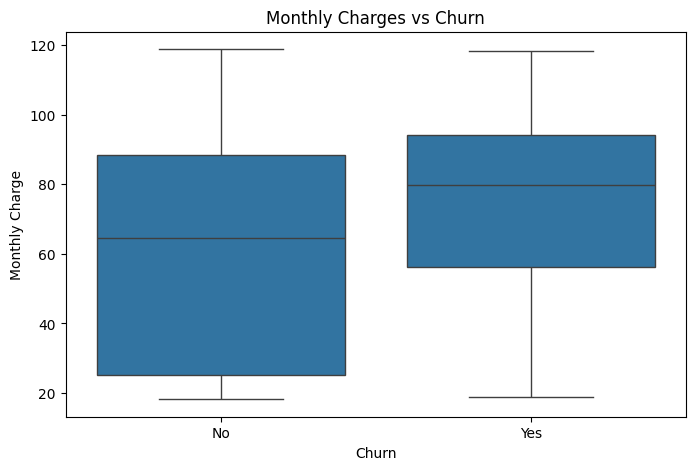

In [18]:
#Does Monthly Charge Affect Churn?
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charge")

plt.show()

Churned customers generally have higher monthly charges than customers who remain, suggesting a relationship between monthly pricing and churn behavior.

In [19]:
#Which Internet Service Customers Churn More?
df["InternetService"].value_counts()

,count
InternetService,
Fiber optic,3096
DSL,2421
No,1526


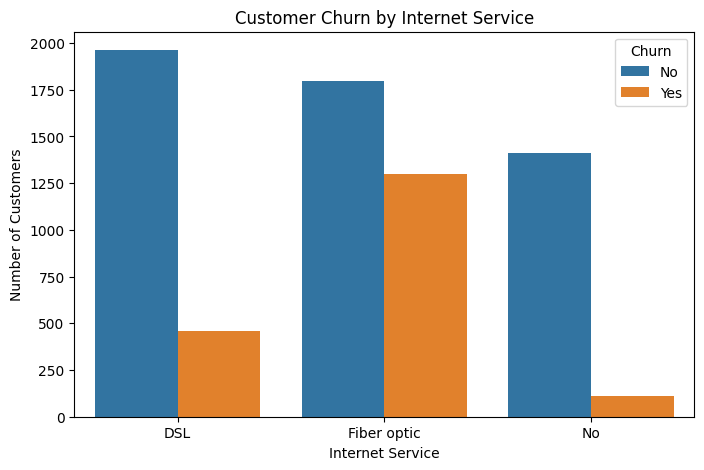

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

In [21]:
#Calculate churn percentage
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
)*100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


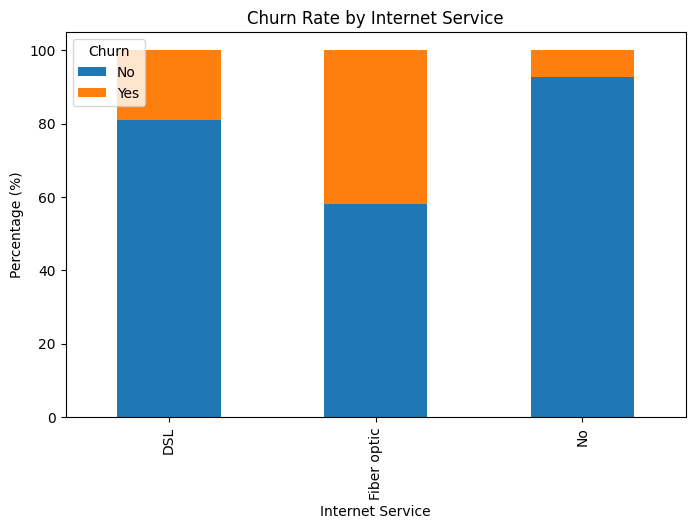

In [22]:
internet_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage (%)")
plt.legend(title="Churn")
plt.show()

Customers using fiber optic service show a higher churn rate compared with DSL and customers without internet service, making internet service type a potentially useful predictive feature.

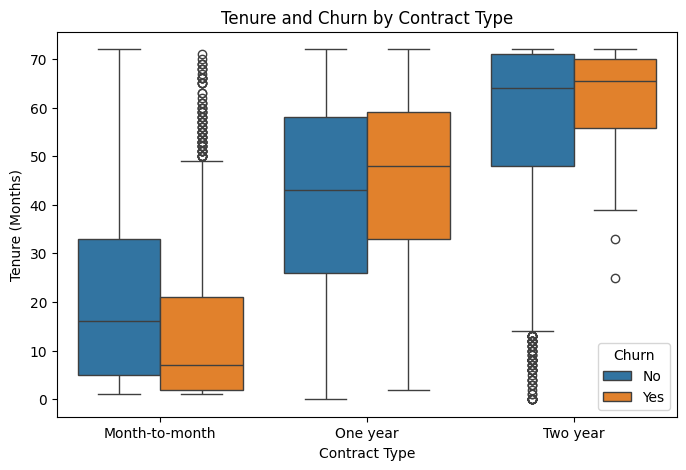

In [23]:
#Is there any relationship between tenure and contract type
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Contract",
    y="tenure",
    hue="Churn"
)

plt.title("Tenure and Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Tenure (Months)")

plt.show()

The boxplot indicates a relationship between contract type, tenure, and churn. Month-to-month customers generally have lower tenure and higher churn, whereas customers with one-year and two-year contracts tend to have longer tenure and lower churn. This suggests that longer-term contracts are associated with greater customer retention.

In [24]:
#Exploratory Data Analysis

In [25]:
#Checking missing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [26]:
df["TotalCharges"].value_counts().tail(10)

,count
TotalCharges,
6565.85,1
2117.2,1
203.95,1
6849.4,1
692.35,1
130.15,1
3211.9,1
7843.55,1
2196.3,1


In [27]:
df[df["TotalCharges"].str.strip() ==""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [28]:
#Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [29]:
#Check duplicate customer IDs:
df["customerID"].duplicated().sum()

np.int64(0)

In [30]:
#Check unique values
for column in df.select_dtypes(include="object").columns:
  print(f"\n{column}")
  print(df[column].unique())


customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender
['Female' 'Male']

Partner
['Yes' 'No']

Dependents
['No' 'Yes']

PhoneService
['No' 'Yes']

MultipleLines
['No phone service' 'No' 'Yes']

InternetService
['DSL' 'Fiber optic' 'No']

OnlineSecurity
['No' 'Yes' 'No internet service']

OnlineBackup
['Yes' 'No' 'No internet service']

DeviceProtection
['No' 'Yes' 'No internet service']

TechSupport
['No' 'Yes' 'No internet service']

StreamingTV
['No' 'Yes' 'No internet service']

StreamingMovies
['No' 'Yes' 'No internet service']

Contract
['Month-to-month' 'One year' 'Two year']

PaperlessBilling
['Yes' 'No']

PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

TotalCharges
['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']

Churn
['No' 'Yes']


In [31]:
#Identify the numerical columns
df.select_dtypes(include=["int64","float64"]).columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')

In [32]:
#Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [34]:
#Inspecting missing values
df["TotalCharges"].isnull().sum()

np.int64(11)

In [35]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


We can see that customer with **Zero Tenure** are the one with **Total Charge NaN**. This can indicate that these are likely newer customers who haven't accumulated charges yet.

In [36]:
#Replace those missing values with 0
df["TotalCharges"]= df["TotalCharges"].fillna(0)

In [37]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [38]:
#Data PreProcessing
#Since customerId is an identifies not a meningful predictive feature it can be dropped

df = df.drop("customerID",axis=1)

In [39]:
df.shape

(7043, 20)

In [40]:
#Convert the target variable

df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

In [41]:
df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [42]:
#More Exploratory Data analysis

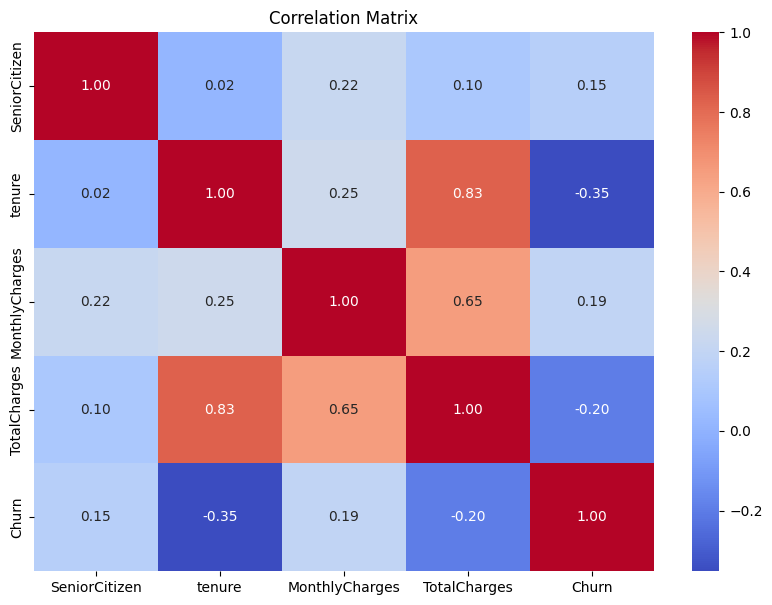

In [43]:
#Correlation matrix
plt.figure(figsize=(10,7))

sns.heatmap(
    df.select_dtypes(include=["int64","float64"]).corr(),
    annot = True,
    cmap = "coolwarm",
    fmt = ".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [44]:
#Separate Features and Target
X = df.drop("Churn",axis =1)
y = df["Churn"]

In [45]:
X.shape

(7043, 19)

In [46]:
y.shape

(7043,)

In [47]:
#Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state =42
)

In [48]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 19)
X_test: (1409, 19)
y_train: (5634,)
y_test: (1409,)


In [49]:
#Identiy Numerical and Categorical Features

In [50]:
numeric_features = X_train.select_dtypes(
    include=["int64","float64"]
).columns.tolist()
print("Numerical Colums:")
numeric_features

Numerical Colums:


['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [51]:
categorical_features = X_train.select_dtypes(
    include = ["object"]
).columns.tolist()
print("Categorical Colums:\n")
categorical_features

Categorical Colums:



['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [52]:
#Transform the Features
#Create the preprocessing pipeline

In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [54]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [55]:
#Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)

In [56]:
X_test_processed = preprocessor.transform(X_test)

In [57]:
#Check the transformed data
print("Training Shape:", X_train_processed.shape)
print("Testing Shape:", X_test_processed.shape)

Training Shape: (5634, 45)
Testing Shape: (1409, 45)


In [58]:
#Convert to Pytorch Tensors

In [59]:
X_train_tensor = torch.tensor(
    X_train_processed,
    dtype = torch.float32
)

X_test_tensor = torch.tensor(
    X_test_processed,
    dtype= torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype= torch.float32
)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype= torch.float32
)

In [60]:
#Verifying Everything
print(X_train_tensor.shape)
print(X_test_tensor.shape)

print(y_train_tensor.shape)
print(y_test_tensor.shape)

torch.Size([5634, 45])
torch.Size([1409, 45])
torch.Size([5634])
torch.Size([1409])


In [61]:
print(X_train_tensor.dtype)
print(y_train_tensor.dtype)

torch.float32
torch.float32


In [62]:
#Creating the training Dataset
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

In [63]:
#Creating the testing Dataset
test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

In [64]:
print(train_dataset)
print(test_dataset)

In [65]:
#Look at one customer
X_sample,y_sample = train_dataset[0]
print("Features: ",X_sample)
print("Label: ",y_sample)

Features:  tensor([-0.4418,  0.1024, -0.5220, -0.2623,  0.0000,  1.0000,  1.0000,  0.0000,
         1.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  1.0000,
         0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  1.0000,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         1.0000,  0.0000,  0.0000,  1.0000,  1.0000,  0.0000,  0.0000,  1.0000,
         0.0000,  0.0000,  0.0000,  1.0000,  0.0000])
Label:  tensor(0.)


In [66]:
train_dataset[0]

(tensor([-0.4418,  0.1024, -0.5220, -0.2623,  0.0000,  1.0000,  1.0000,  0.0000,
          1.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  1.0000,
          0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  1.0000,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          1.0000,  0.0000,  0.0000,  1.0000,  1.0000,  0.0000,  0.0000,  1.0000,
          0.0000,  0.0000,  0.0000,  1.0000,  0.0000]),
 tensor(0.))

In [67]:
#Create the DataLoader
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)